# mRmR Feature Selection — Example Notebook

Demonstrates **P1 `mRmRSelector`** on the SCANB gene-expression dataset.

| Task | Target | Type | Relevance | Mode |
|------|--------|------|-----------|------|
| **A** | `is_lumA` | classification | `pearson` | precomputed matrix |
| **B** | `Lympho` | regression | `pearson` | precomputed matrix |
| **C** | `is_lumA` | classification | `mutual_information`, `random_forest`, `f_statistic` | precomputed relevance files |
| **D** | `Lympho` | regression | `mutual_information`, `random_forest`, `f_statistic` | precomputed relevance files |
| **E** | both | both | all methods | lazy hot-cache, 10 features, timing comparison |

**P1 features demonstrated:**
- `eval_every_k` — evaluate every 5 steps (Tasks A–D use 50 features)
- `'step'` key in `performance_history`
- `LR_random_baseline / LR_regression_baseline` with `return_summary=True`
- `selector.plot_vs_random_baseline(result, baseline_summary)`
- `FeatureRelevanceScores` — precomputed non-correlation relevance
- Lazy hot-cache timing comparison (Task E)

## 0 — Imports & paths

In [1]:
import sys, os

# Make sure the package root is on the path when running from feature_selection/src/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from feature_selection.src.preprocessing import train_test_val_split
from feature_selection.src.filter.mRmR import mRmRSelector
from feature_selection.src.results import SelectionResult
from feature_selection.src.LR_random_baseline import plot_performance_with_stats as clf_baseline_plot
from feature_selection.src.LR_regression_baseline import plot_performance_with_stats as reg_baseline_plot

# ── Paths (relative to notebook location: feature_selection/src/) ──────────
DATA_PATH  = '../data/SCANB.csv'
LABEL_PATH = '../data/sampleinfo_SCANB_t.csv'
CORR_PATH  = '../data/correlation_matrix.csv'  # 9 266 features + is_lumA + Lympho

# Precomputed relevance score files (Tasks C / D) — created on first run
REL_MI_CLF_PATH  = '../data/rel_mi_clf.csv'
REL_RF_CLF_PATH  = '../data/rel_rf_clf.csv'
REL_FS_CLF_PATH  = '../data/rel_fs_clf.csv'
REL_MI_REG_PATH  = '../data/rel_mi_reg.csv'
REL_RF_REG_PATH  = '../data/rel_rf_reg.csv'
REL_FS_REG_PATH  = '../data/rel_fs_reg.csv'

RANDOM_SEED  = 2
N_FEATURES   = 30    # Tasks A–D
EVAL_EVERY_K = 2
N_RUNS       = 10    # baseline runs

## 1 — Load data & build train / validation splits

In [2]:
gene_expression_df = pd.read_csv(DATA_PATH)
sampleinfo_df      = pd.read_csv(LABEL_PATH)

# Binary LumA label
sampleinfo_df['is_lumA'] = (sampleinfo_df['PAM50'] == 'LumA').astype(int)

# 70 % train / 10 % val / 20 % test
train_si, val_si, _ = train_test_val_split(
    sampleinfo_df, random_seed=RANDOM_SEED, train_pcnt=0.7, val_pct=0.1
)

train_labels_df = train_si[['samplename', 'is_lumA']].reset_index(drop=True)
val_labels_df   = val_si[['samplename', 'is_lumA']].reset_index(drop=True)

print(f'Train samples : {len(train_labels_df)}')
print(f'Val   samples : {len(val_labels_df)}')
print(f"LumA prevalence (train): {train_labels_df['is_lumA'].mean():.2%}")

# Transpose gene-expression (genes × samples) → (samples × genes)
ge_proc = gene_expression_df.copy().fillna(0).set_index('Unnamed: 0').T
ge_proc.index.name = 'samplename'

X_train = ge_proc.loc[train_labels_df['samplename']]
X_val   = ge_proc.loc[val_labels_df['samplename']]

print(f'\nX_train shape : {X_train.shape}')
print(f'X_val   shape : {X_val.shape}')

Train samples : 2148
Val   samples : 306
LumA prevalence (train): 49.30%

X_train shape : (2148, 9264)
X_val   shape : (306, 9264)


## 2 — Build target series

Both targets are already stored in `correlation_matrix.csv` under their real column names.

In [3]:
# Classification target: is_lumA
y_lumA = (
    train_labels_df.set_index('samplename')['is_lumA']
    .reindex(X_train.index)
)  # Series.name == 'is_lumA'

y_lumA_val = (
    val_labels_df.set_index('samplename')['is_lumA']
    .reindex(X_val.index)
)

# Regression target: Lympho
y_lympho = (
    sampleinfo_df.set_index('samplename')['Lympho']
    .reindex(X_train.index)
)  # Series.name == 'Lympho'

y_lympho_val = (
    sampleinfo_df.set_index('samplename')['Lympho']
    .reindex(X_val.index)
)

print(f'y_lumA   name={y_lumA.name!r}    dtype={y_lumA.dtype}   nunique={y_lumA.nunique()}')
print(f'y_lympho name={y_lympho.name!r}  dtype={y_lympho.dtype}   nunique={y_lympho.nunique()}')

y_lumA   name='is_lumA'    dtype=int64   nunique=2
y_lympho name='Lympho'  dtype=float64   nunique=2148


---

## Task A — Classification (Pearson, precomputed matrix)

### A.1 — Run mRmR selector

In [4]:
selector_clf = mRmRSelector(
    X_train=X_train,
    y_train=y_lumA,
    relevance_method='pearson',
    mrmr_score_method='difference',
    correlation_filepath=CORR_PATH,
    gene_expression_df=gene_expression_df,
    train_labels_df=train_labels_df,
    val_labels_df=val_labels_df,
    random_seed=RANDOM_SEED,
)

result_clf: SelectionResult = selector_clf.forward_selection(
    n_features_to_select=N_FEATURES,
    eval_every_k=EVAL_EVERY_K,
)

print()
print(result_clf)

2026-04-06 12:14:14,413 [INFO] mRmRSelector: mRmRSelector initialised | task_type=classification | target_col=is_lumA | relevance_method=pearson | redundancy_method=pearson | mrmr_score_method=difference
Correlation matrix loaded from ../data/correlation_matrix.csv
2026-04-06 12:14:39,393 [INFO] mRmRSelector: Loaded correlation matrix from ../data/correlation_matrix.csv (9266, 9266)
2026-04-06 12:14:41,099 [INFO] mRmRSelector: Starting forward selection for up to 30 features (eval_every_k=2)
2026-04-06 12:14:41,123 [INFO] mRmRSelector: Step 1: selected 'MYBL2' (1 total)
2026-04-06 12:14:41,125 [INFO] mRmRSelector: Step 1: evaluation skipped (eval_every_k=2)
2026-04-06 12:14:41,242 [INFO] mRmRSelector: Step 2: selected 'ATP13A2' (2 total)
2026-04-06 12:14:41,637 [INFO] mRmRSelector: Step 2 eval — accuracy: 0.8007  macro F1: 0.8007
2026-04-06 12:14:41,775 [INFO] mRmRSelector: Step 3: selected 'SLC24A2' (3 total)
2026-04-06 12:14:41,776 [INFO] mRmRSelector: Step 3: evaluation skipped (eva

### A.2 — Selected features

In [5]:
print('Classification — selected features (in order):')
for i, f in enumerate(result_clf.selected_features, 1):
    print(f'  {i:2d}. {f}')

Classification — selected features (in order):
   1. MYBL2
   2. ATP13A2
   3. SLC24A2
   4. SHCBP1
   5. PGR
   6. BIRC5
   7. TMPRSS3
   8. MAPT
   9. TUBA1B
  10. MATN3
  11. CALML3
  12. CDC45
  13. EVL
  14. PTTG1
  15. FLNB
  16. FAM189A1
  17. POLQ
  18. NAT1
  19. TROAP
  20. MTHFR
  21. STC2
  22. NEFH
  23. ORC6
  24. DNAAF1
  25. CDKN3
  26. CDC37L1
  27. NEIL3
  28. IGFALS
  29. FST
  30. CDC25B


In [6]:
# Inspect first history entry — includes 'step' key (P1 G1)
result_clf.performance_history[0]

{'0': {'precision': 0.782051282051282,
  'recall': 0.8187919463087249,
  'f1-score': 0.8,
  'support': 149.0},
 '1': {'precision': 0.82,
  'recall': 0.7834394904458599,
  'f1-score': 0.8013029315960912,
  'support': 157.0},
 'accuracy': 0.8006535947712419,
 'macro avg': {'precision': 0.801025641025641,
  'recall': 0.8011157183772923,
  'f1-score': 0.8006514657980457,
  'support': 306.0},
 'weighted avg': {'precision': 0.8015217026981732,
  'recall': 0.8006535947712419,
  'f1-score': 0.8006684975836155,
  'support': 306.0},
 'step': 2}

### A.3 — LR random baseline

Running experiments: 100%|██████████| 10/10 [01:05<00:00,  6.57s/it]


Summary Statistics (Mean +/- Std Dev):



,features_num,variable,mean,std
0,2,f1-score,0.604881,0.034663
1,2,precision,0.605392,0.034584
2,2,recall,0.605198,0.034504
3,4,f1-score,0.645082,0.050261
4,4,precision,0.646274,0.050569
5,4,recall,0.645441,0.049934
6,6,f1-score,0.687868,0.051807
7,6,precision,0.689053,0.052302
8,6,recall,0.688033,0.051944
9,8,f1-score,0.701096,0.044530


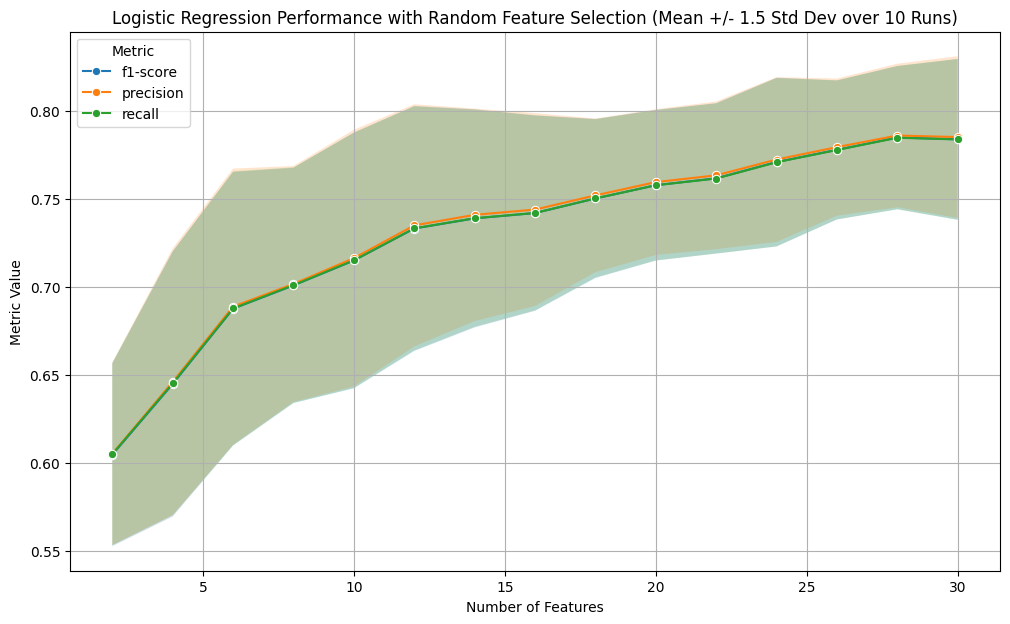

In [7]:
# Checkpoints align with evaluated steps (every 5th)
checkpoints_clf = [entry['step'] for entry in result_clf.performance_history]

baseline_summary_clf = clf_baseline_plot(
    gene_expression_df=gene_expression_df,
    train_labels_df=train_labels_df,
    val_labels_df=val_labels_df,
    N_values=checkpoints_clf,
    random_seed=RANDOM_SEED,
    num_runs=N_RUNS,
    return_summary=True,
)

### A.4 — Comparison plot


Summary Statistics — Random Baseline (Mean ± Std):


,features_num,acc_mean,acc_std,f1_mean,f1_std
0,2,0.605229,0.034715,0.604881,0.034663
1,4,0.645752,0.050538,0.645082,0.050261
2,6,0.688562,0.051810,0.687868,0.051807
3,8,0.701634,0.044411,0.701096,0.044530
4,10,0.716013,0.048434,0.715280,0.048491
5,12,0.734314,0.046012,0.733422,0.046414
6,14,0.740196,0.040708,0.739194,0.041332
7,16,0.743137,0.036657,0.742214,0.037037
8,18,0.751307,0.029651,0.750495,0.030141
9,20,0.758824,0.028104,0.758029,0.028556


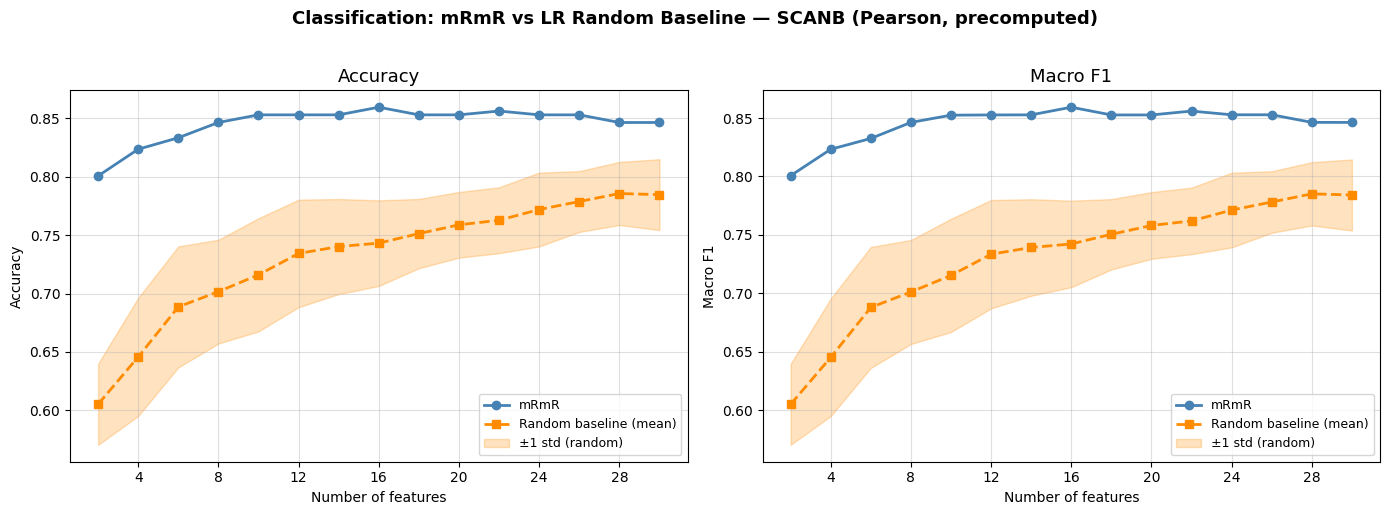

In [8]:
result_clf.plot_vs_random_baseline(
    baseline_summary=baseline_summary_clf,
    title_suffix=' — SCANB (Pearson, precomputed)',
)

---

## Task B — Regression (Pearson, precomputed matrix)

### B.1 — Run mRmR selector

In [9]:
selector_reg = mRmRSelector(
    X_train=X_train,
    y_train=y_lympho,
    relevance_method='pearson',
    mrmr_score_method='difference',
    correlation_filepath=CORR_PATH,
    random_seed=RANDOM_SEED,
    X_val=X_val,
    y_val=y_lympho_val,
)

result_reg: SelectionResult = selector_reg.forward_selection(
    n_features_to_select=N_FEATURES,
    eval_every_k=EVAL_EVERY_K,
)

print()
print(result_reg)

2026-04-06 12:16:10,500 [INFO] mRmRSelector: mRmRSelector initialised | task_type=regression | target_col=Lympho | relevance_method=pearson | redundancy_method=pearson | mrmr_score_method=difference
Correlation matrix loaded from ../data/correlation_matrix.csv
2026-04-06 12:16:34,516 [INFO] mRmRSelector: Loaded correlation matrix from ../data/correlation_matrix.csv (9266, 9266)
2026-04-06 12:16:36,113 [INFO] mRmRSelector: Starting forward selection for up to 30 features (eval_every_k=2)
2026-04-06 12:16:36,142 [INFO] mRmRSelector: Step 1: selected 'LCK' (1 total)
2026-04-06 12:16:36,143 [INFO] mRmRSelector: Step 1: evaluation skipped (eval_every_k=2)
2026-04-06 12:16:36,253 [INFO] mRmRSelector: Step 2: selected 'NLRP3' (2 total)
2026-04-06 12:16:36,264 [INFO] mRmRSelector: Step 2 eval — r2: 0.9476  mse: 0.0478  mae: 0.1723
2026-04-06 12:16:36,401 [INFO] mRmRSelector: Step 3: selected 'CD19' (3 total)
2026-04-06 12:16:36,403 [INFO] mRmRSelector: Step 3: evaluation skipped (eval_every_k=

### B.2 — Selected features & relevance bar chart

In [12]:
print('Regression — selected features (in order):')
for i, f in enumerate(result_reg.selected_features, 1):
    print(f'  {i:2d}. {f}')

# target_col = selector_reg._target_col
# rel_scores = {
#     f: selector_reg._score_arr[i, target_col]
#     for f in result_reg.selected_features
# }
# rel_df = (
#     pd.Series(rel_scores, name='|Pearson| with Lympho')
#     .reset_index().rename(columns={'index': 'feature'})
#     .sort_values('|Pearson| with Lympho', ascending=False)
#     .reset_index(drop=True)
# )

# fig, ax = plt.subplots(figsize=(8, 5))
# ax.barh(rel_df['feature'][::-1], rel_df['|Pearson| with Lympho'][::-1],
#         color='teal', alpha=0.8)
# ax.set_xlabel('|Pearson correlation with Lympho|')
# ax.set_title(f'Top {N_FEATURES} mRmR features — Regression task (Lympho)', fontsize=12)
# ax.grid(True, axis='x', alpha=0.4)
# plt.tight_layout()
# plt.show()

# display(rel_df)

Regression — selected features (in order):
   1. LCK
   2. NLRP3
   3. CD19
   4. FASLG
   5. IL2RG
   6. CCR7
   7. SLAMF7
   8. ACAP1
   9. ITK
  10. PRKCB
  11. TRAF3IP3
  12. CD27
  13. PRF1
  14. MAP4K1
  15. BIRC3
  16. SH2D1A
  17. ARHGAP25
  18. CD3G
  19. CD79B
  20. CD48
  21. ICOS
  22. LY9
  23. PTPRC
  24. CD247
  25. HLA-DOB
  26. ZAP70
  27. PLAC8
  28. PTPN7
  29. PYHIN1
  30. SLAMF1


### B.3 — LinReg random baseline

Running LinReg experiments: 100%|██████████| 10/10 [00:01<00:00,  7.84it/s]


Summary Statistics — Linear Regression Random Baseline (Mean ± Std):



,features_num,r2_mean,r2_std,mse_mean,mse_std,mae_mean,mae_std
0,2,0.101507,0.128125,0.819435,0.116851,0.707897,0.057209
1,4,0.213759,0.162417,0.717060,0.148126,0.656454,0.072793
2,6,0.303753,0.245762,0.634984,0.224138,0.611114,0.134488
3,8,0.337230,0.240140,0.604453,0.219010,0.596585,0.132432
4,10,0.340860,0.237768,0.601142,0.216847,0.593072,0.131326
5,12,0.381314,0.223988,0.564248,0.204279,0.572678,0.124453
6,14,0.402052,0.223804,0.545335,0.204111,0.561303,0.132088
7,16,0.476534,0.199025,0.477406,0.181513,0.528068,0.120207
8,18,0.487832,0.206206,0.467102,0.188062,0.519213,0.124556
9,20,0.539917,0.202442,0.419600,0.184629,0.494015,0.120208


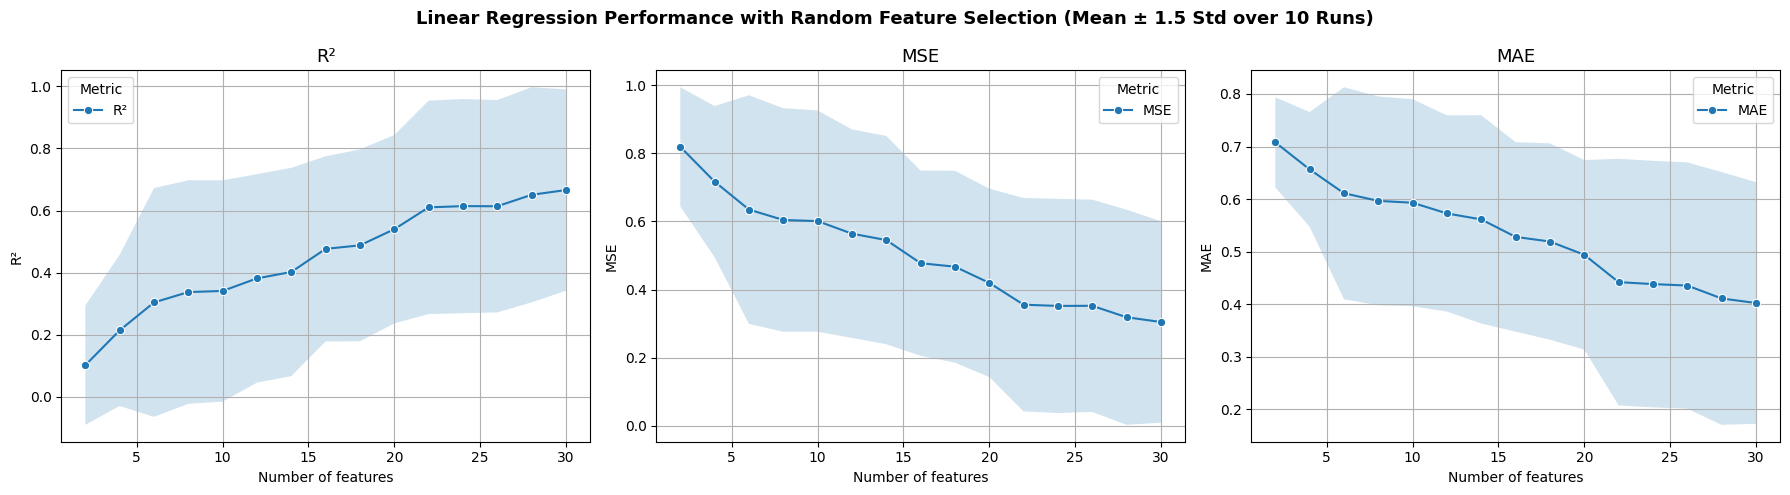

In [13]:
checkpoints_reg = [entry['step'] for entry in result_reg.performance_history]

baseline_summary_reg = reg_baseline_plot(
    X_train=X_train,
    y_train=y_lympho,
    X_val=X_val,
    y_val=y_lympho_val,
    N_values=checkpoints_reg,
    random_seed=RANDOM_SEED,
    num_runs=N_RUNS,
    return_summary=True,
)

### B.4 — Comparison plot


Summary Statistics — LinReg Random Baseline (Mean ± Std):


,features_num,r2_mean,r2_std,mse_mean,mse_std,mae_mean,mae_std
0,2,0.101507,0.128125,0.819435,0.116851,0.707897,0.057209
1,4,0.213759,0.162417,0.717060,0.148126,0.656454,0.072793
2,6,0.303753,0.245762,0.634984,0.224138,0.611114,0.134488
3,8,0.337230,0.240140,0.604453,0.219010,0.596585,0.132432
4,10,0.340860,0.237768,0.601142,0.216847,0.593072,0.131326
5,12,0.381314,0.223988,0.564248,0.204279,0.572678,0.124453
6,14,0.402052,0.223804,0.545335,0.204111,0.561303,0.132088
7,16,0.476534,0.199025,0.477406,0.181513,0.528068,0.120207
8,18,0.487832,0.206206,0.467102,0.188062,0.519213,0.124556
9,20,0.539917,0.202442,0.419600,0.184629,0.494015,0.120208


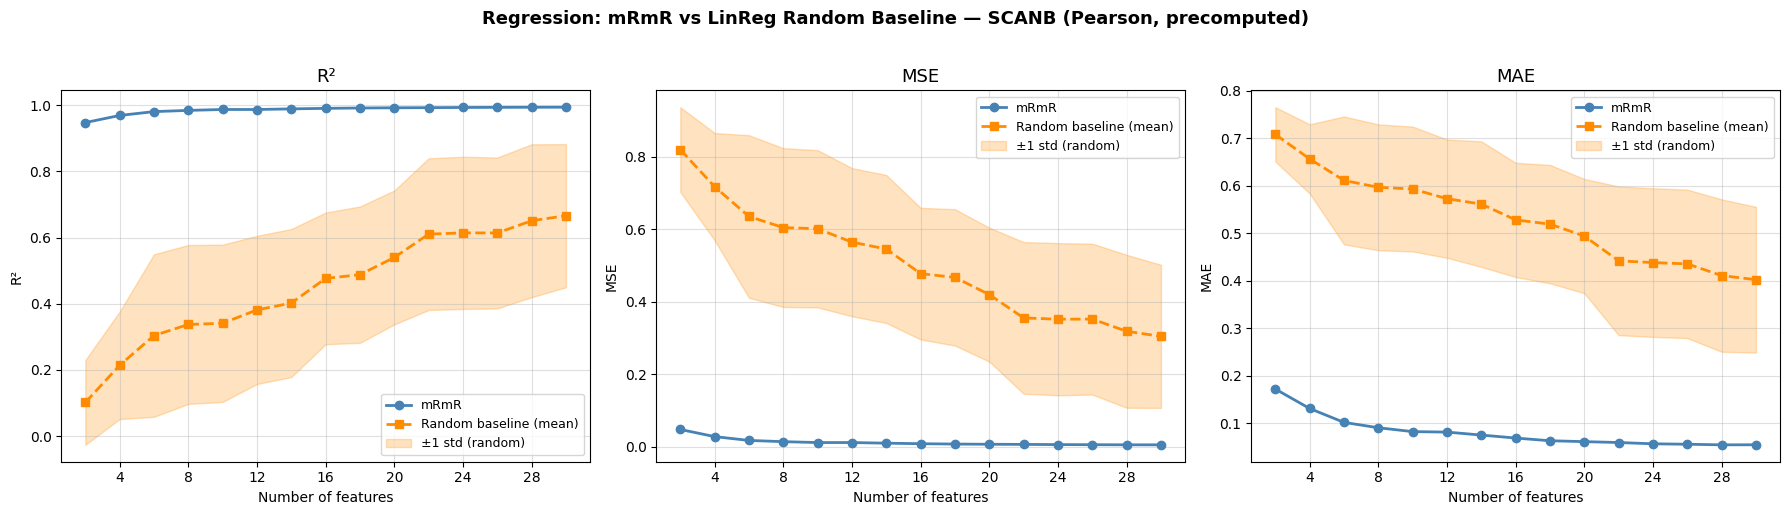

In [14]:
result_reg.plot_vs_random_baseline(
    baseline_summary=baseline_summary_reg,
    title_suffix=' — SCANB (Pearson, precomputed)',
)

---

## Task C — Classification: non-correlation relevance methods (precomputed files)

Runs `mutual_information`, `random_forest`, and `f_statistic` for the `is_lumA` target.  
Each selector uses a precomputed relevance scores file (created on first run, reloaded thereafter).  
Redundancy uses the same precomputed Pearson matrix (`CORR_PATH`).  
50 features selected, evaluation every 5 steps.  Performance histories are compared across methods.

### C.1 — Run all three non-correlation selectors

In [18]:
non_corr_methods_clf = [
    ('mutual_information', REL_MI_CLF_PATH),
    ('random_forest',      REL_RF_CLF_PATH),
    ('f_statistic',        REL_FS_CLF_PATH),
]

results_C = {}   # method → SelectionResult

for method, rel_path in non_corr_methods_clf:
    print(f'\n=== Classification | relevance_method={method!r} ===')
    sel = mRmRSelector(
        X_train=X_train,
        y_train=y_lumA,
        relevance_method=method,
        redundancy_method='pearson',        # pairwise correlation for redundancy
        mrmr_score_method= 'difference' if method == 'pearson' else 'ratio',
        correlation_filepath=CORR_PATH,     # reuse Pearson matrix for redundancy
        relevance_scores_filepath=rel_path, # precomputed file (Mode A)
        gene_expression_df=gene_expression_df,
        train_labels_df=train_labels_df,
        val_labels_df=val_labels_df,
        random_seed=RANDOM_SEED,
    )
    result = sel.forward_selection(
        n_features_to_select=N_FEATURES,
        eval_every_k=EVAL_EVERY_K,
    )
    results_C[method] = result
    print(result)


=== Classification | relevance_method='mutual_information' ===
2026-04-06 12:28:17,961 [INFO] mRmRSelector: mRmRSelector initialised | task_type=classification | target_col=is_lumA | relevance_method=mutual_information | redundancy_method=pearson | mrmr_score_method=ratio
Relevance scores loaded from ../data/rel_mi_clf.csv (9264 features)
2026-04-06 12:28:17,983 [INFO] mRmRSelector: Loaded relevance scores from ../data/rel_mi_clf.csv (9264 features)
Correlation matrix loaded from ../data/correlation_matrix.csv
2026-04-06 12:28:39,351 [INFO] mRmRSelector: Loaded redundancy matrix from ../data/correlation_matrix.csv (9266, 9266)
2026-04-06 12:28:41,099 [INFO] mRmRSelector: Starting forward selection for up to 30 features (eval_every_k=2)
2026-04-06 12:28:41,125 [INFO] mRmRSelector: Step 1: selected 'CCNA2' (1 total)
2026-04-06 12:28:41,127 [INFO] mRmRSelector: Step 1: evaluation skipped (eval_every_k=2)
2026-04-06 12:28:41,344 [INFO] mRmRSelector: Step 2: selected 'GSTT1' (2 total)
2026

### C.2 — Compare performance history across methods

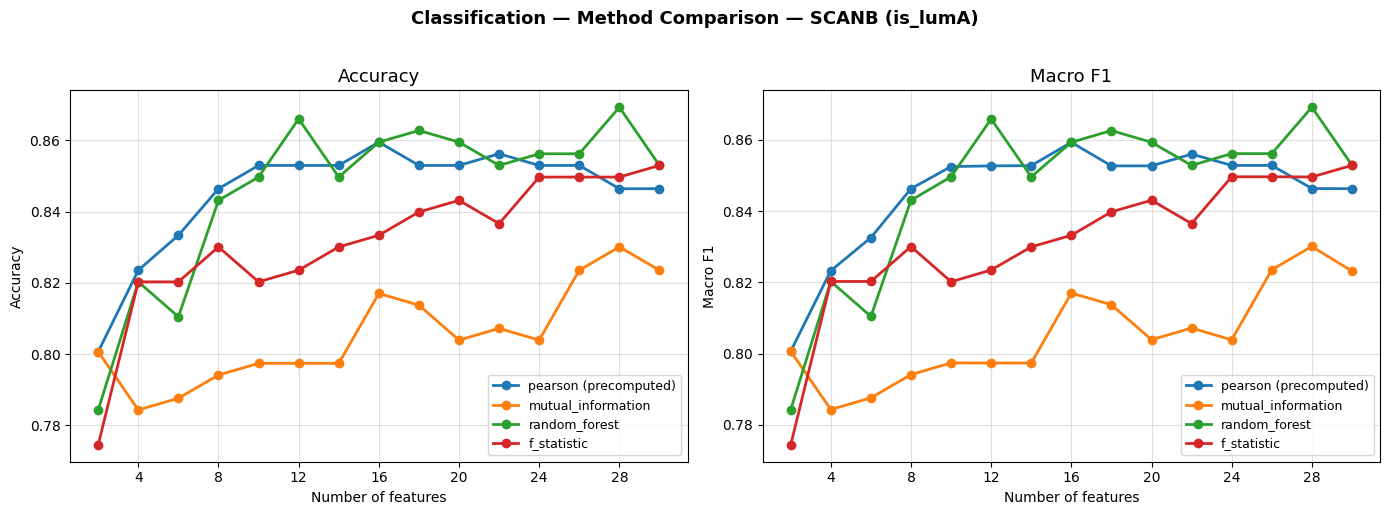

In [26]:
# Also include the Pearson result from Task A for reference
all_clf_results = {
    'pearson (precomputed)': result_clf,
    **{m: results_C[m] for m, _ in non_corr_methods_clf},
}

SelectionResult.compare_results(
    results=list(all_clf_results.values()),
    labels=list(all_clf_results.keys()),
    title_suffix=' — SCANB (is_lumA)',
)

---

## Task D — Regression: non-correlation relevance methods (precomputed files)

Same structure as Task C but for the `Lympho` regression target.  
Performance histories (R², MSE, MAE) are compared across methods.

### D.1 — Run all three non-correlation selectors

In [19]:
non_corr_methods_reg = [
    ('mutual_information', REL_MI_REG_PATH),
    ('random_forest',      REL_RF_REG_PATH),
    ('f_statistic',        REL_FS_REG_PATH),
]

results_D = {}   # method → SelectionResult

for method, rel_path in non_corr_methods_reg:
    print(f'\n=== Regression | relevance_method={method!r} ===')
    sel = mRmRSelector(
        X_train=X_train,
        y_train=y_lympho,
        relevance_method=method,
        redundancy_method='pearson',
        mrmr_score_method='difference' if method == 'pearson' else 'ratio',
        correlation_filepath=CORR_PATH,
        relevance_scores_filepath=rel_path,
        random_seed=RANDOM_SEED,
        X_val=X_val,
        y_val=y_lympho_val,
    )
    result = sel.forward_selection(
        n_features_to_select=N_FEATURES,
        eval_every_k=EVAL_EVERY_K,
    )
    results_D[method] = result
    print(result)


=== Regression | relevance_method='mutual_information' ===
2026-04-06 12:30:28,237 [INFO] mRmRSelector: mRmRSelector initialised | task_type=regression | target_col=Lympho | relevance_method=mutual_information | redundancy_method=pearson | mrmr_score_method=ratio
Relevance scores loaded from ../data/rel_mi_reg.csv (9264 features)
2026-04-06 12:30:28,259 [INFO] mRmRSelector: Loaded relevance scores from ../data/rel_mi_reg.csv (9264 features)
Correlation matrix loaded from ../data/correlation_matrix.csv
2026-04-06 12:30:51,608 [INFO] mRmRSelector: Loaded redundancy matrix from ../data/correlation_matrix.csv (9266, 9266)
2026-04-06 12:30:53,478 [INFO] mRmRSelector: Starting forward selection for up to 30 features (eval_every_k=2)
2026-04-06 12:30:53,512 [INFO] mRmRSelector: Step 1: selected 'CD3E' (1 total)
2026-04-06 12:30:53,515 [INFO] mRmRSelector: Step 1: evaluation skipped (eval_every_k=2)
2026-04-06 12:30:53,691 [INFO] mRmRSelector: Step 2: selected 'B3GALT5' (2 total)
2026-04-06 1

### D.2 — Compare performance history across methods

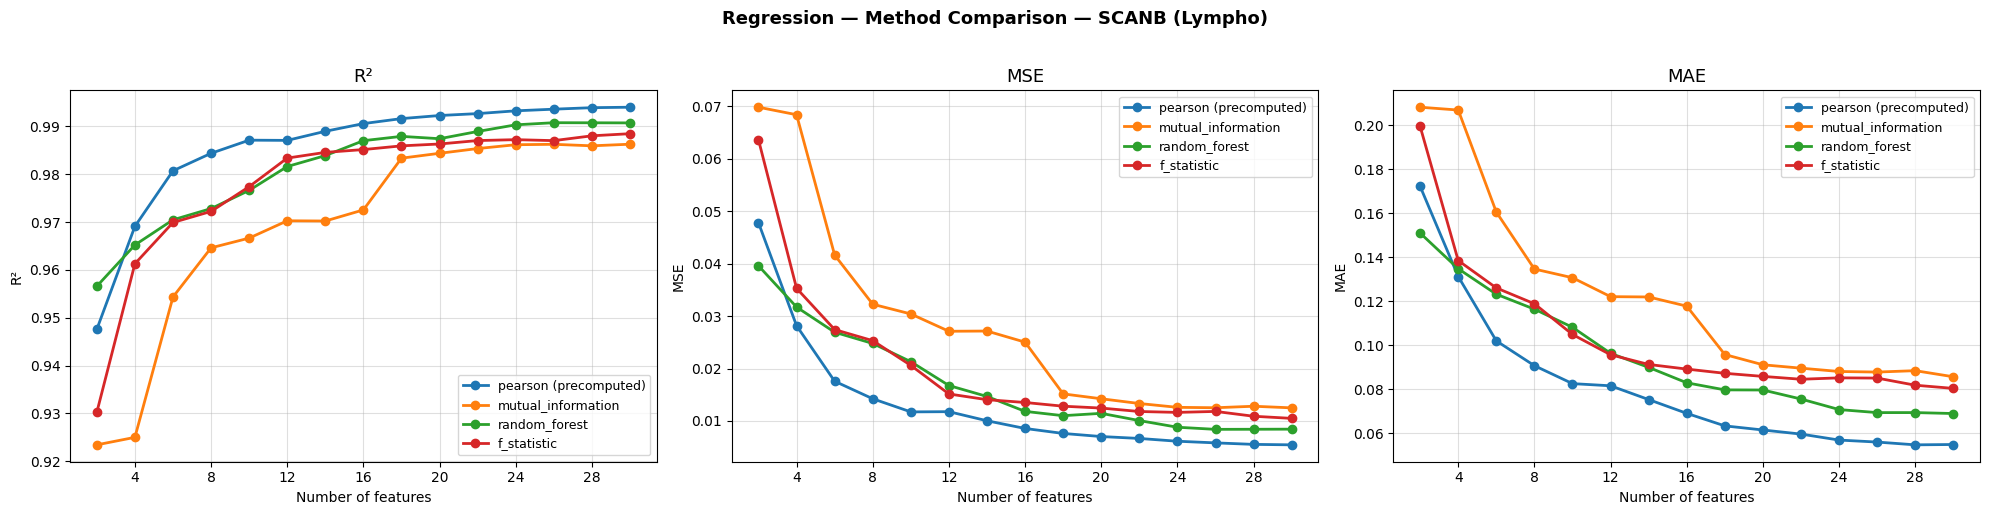

In [20]:
all_reg_results = {
    'pearson (precomputed)': result_reg,
    **{m: results_D[m] for m, _ in non_corr_methods_reg},
}

SelectionResult.compare_results(
    results=list(all_reg_results.values()),
    labels=list(all_reg_results.keys()),
    title_suffix=' — SCANB (Lympho)',
)

---

## Task E — Lazy hot-cache timing comparison (10 features)

All relevance methods run **without** a precomputed file — scores are computed
lazily on first access and cached in memory (`_relevance_cache` / `_score_matrix`).

- Pearson correlation: lazy hot-cache from the full `_score_matrix` (no precomputed file, standard Mode B)
- `mutual_information`, `random_forest`, `f_statistic`: lazy `_relevance_cache` per feature
- No evaluation (no LR/LinReg eval params) — `selection_time_seconds` measures pure mRmR scoring
- 10 features selected; average time per feature = `selection_time_seconds / 10`

Both classification and regression targets are timed and summarised together.

### E.1 — Run lazy-cache selectors (classification)

In [21]:
N_LAZY = 10   # number of features for timing experiment

# Methods to bench for classification (pearson only from correlation family)
lazy_methods_clf = [
    ('pearson',            None),   # correlation — lazy Mode B, no relevance_scores_filepath
    ('mutual_information', None),
    ('random_forest',      None),
    ('f_statistic',        None),
]

timing_records_clf = []

for method, _ in lazy_methods_clf:
    kwargs = dict(
        X_train=X_train,
        y_train=y_lumA,
        relevance_method=method,
        mrmr_score_method='difference' if method == 'pearson' else 'ratio',
        random_seed=RANDOM_SEED,
        # No correlation_filepath → lazy Mode B for correlation method too
        # No relevance_scores_filepath → lazy hot-cache for non-corr methods
    )
    if method in ('mutual_information', 'random_forest', 'f_statistic'):
        kwargs['redundancy_method'] = 'pearson'

    sel = mRmRSelector(**kwargs)
    res = sel.forward_selection(n_features_to_select=N_LAZY)

    avg_time = res.selection_time_seconds / N_LAZY
    timing_records_clf.append({
        'method': method,
        'task': 'classification',
        'total_selection_time_s': round(res.selection_time_seconds, 4),
        'avg_time_per_feature_s': round(avg_time, 4),
    })
    print(f'{method:25s}  total={res.selection_time_seconds:.3f}s  avg/feature={avg_time:.4f}s')

2026-04-06 12:32:15,315 [INFO] mRmRSelector: mRmRSelector initialised | task_type=classification | target_col=is_lumA | relevance_method=pearson | redundancy_method=pearson | mrmr_score_method=difference
2026-04-06 12:32:15,325 [INFO] mRmRSelector: No correlation filepath — lazy on-demand scoring active
2026-04-06 12:32:15,326 [INFO] mRmRSelector: Starting forward selection for up to 10 features (eval_every_k=1)


/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


2026-04-06 12:32:20,442 [INFO] mRmRSelector: Bulk correlation init complete (pearson, 9265×9265)
2026-04-06 12:32:20,472 [INFO] mRmRSelector: Step 1: selected 'MYBL2' (1 total)
2026-04-06 12:32:20,576 [INFO] mRmRSelector: Step 2: selected 'ATP13A2' (2 total)
2026-04-06 12:32:20,710 [INFO] mRmRSelector: Step 3: selected 'SLC24A2' (3 total)
2026-04-06 12:32:20,852 [INFO] mRmRSelector: Step 4: selected 'SHCBP1' (4 total)
2026-04-06 12:32:21,012 [INFO] mRmRSelector: Step 5: selected 'PGR' (5 total)
2026-04-06 12:32:21,235 [INFO] mRmRSelector: Step 6: selected 'BIRC5' (6 total)
2026-04-06 12:32:21,427 [INFO] mRmRSelector: Step 7: selected 'TMPRSS3' (7 total)
2026-04-06 12:32:21,655 [INFO] mRmRSelector: Step 8: selected 'MAPT' (8 total)
2026-04-06 12:32:21,856 [INFO] mRmRSelector: Step 9: selected 'TUBA1B' (9 total)
2026-04-06 12:32:22,070 [INFO] mRmRSelector: Step 10: selected 'MATN3' (10 total)
2026-04-06 12:32:22,072 [INFO] mRmRSelector: Selection complete: 10 features, reason=max_feature

/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


2026-04-06 12:34:03,351 [INFO] mRmRSelector: Bulk correlation init complete (pearson, 9265×9265)
2026-04-06 12:34:03,454 [INFO] mRmRSelector: Step 2: selected 'GSTT1' (2 total)
2026-04-06 12:34:03,583 [INFO] mRmRSelector: Step 3: selected 'DAZ2' (3 total)
2026-04-06 12:34:03,720 [INFO] mRmRSelector: Step 4: selected 'MUT' (4 total)
2026-04-06 12:34:03,865 [INFO] mRmRSelector: Step 5: selected 'SYCP1' (5 total)
2026-04-06 12:34:04,022 [INFO] mRmRSelector: Step 6: selected 'ANP32D' (6 total)
2026-04-06 12:34:04,201 [INFO] mRmRSelector: Step 7: selected 'TSPAN12' (7 total)
2026-04-06 12:34:04,443 [INFO] mRmRSelector: Step 8: selected 'PGAP3' (8 total)
2026-04-06 12:34:04,637 [INFO] mRmRSelector: Step 9: selected 'DSCAM' (9 total)
2026-04-06 12:34:04,836 [INFO] mRmRSelector: Step 10: selected 'NLRP2' (10 total)
2026-04-06 12:34:04,838 [INFO] mRmRSelector: Selection complete: 10 features, reason=max_features_reached
2026-04-06 12:34:04,839 [INFO] mRmRSelector: Selection time: 102.608s
mutua

/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


2026-04-06 12:34:28,416 [INFO] mRmRSelector: Bulk correlation init complete (pearson, 9265×9265)
2026-04-06 12:34:28,520 [INFO] mRmRSelector: Step 2: selected 'TSPAN13' (2 total)
2026-04-06 12:34:28,672 [INFO] mRmRSelector: Step 3: selected 'HUNK' (3 total)
2026-04-06 12:34:28,800 [INFO] mRmRSelector: Step 4: selected 'ORC1' (4 total)
2026-04-06 12:34:28,936 [INFO] mRmRSelector: Step 5: selected 'MYBL2' (5 total)
2026-04-06 12:34:29,089 [INFO] mRmRSelector: Step 6: selected 'CDC45' (6 total)
2026-04-06 12:34:29,268 [INFO] mRmRSelector: Step 7: selected 'KIF23' (7 total)
2026-04-06 12:34:29,452 [INFO] mRmRSelector: Step 8: selected 'PGR' (8 total)
2026-04-06 12:34:29,640 [INFO] mRmRSelector: Step 9: selected 'EIF2S2' (9 total)
2026-04-06 12:34:29,836 [INFO] mRmRSelector: Step 10: selected 'PTTG1' (10 total)
2026-04-06 12:34:29,837 [INFO] mRmRSelector: Selection complete: 10 features, reason=max_features_reached
2026-04-06 12:34:29,838 [INFO] mRmRSelector: Selection time: 24.858s
random_

/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [1982 3346 4236 4340 8823] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


2026-04-06 12:34:34,617 [INFO] mRmRSelector: Bulk correlation init complete (pearson, 9265×9265)
2026-04-06 12:34:34,712 [INFO] mRmRSelector: Step 2: selected 'KRT37' (2 total)
2026-04-06 12:34:34,815 [INFO] mRmRSelector: Step 3: selected 'IGSF3' (3 total)
2026-04-06 12:34:34,930 [INFO] mRmRSelector: Step 4: selected 'CDC45' (4 total)
2026-04-06 12:34:35,063 [INFO] mRmRSelector: Step 5: selected 'ORC6' (5 total)
2026-04-06 12:34:35,245 [INFO] mRmRSelector: Step 6: selected 'CENPA' (6 total)
2026-04-06 12:34:35,439 [INFO] mRmRSelector: Step 7: selected 'SHCBP1' (7 total)
2026-04-06 12:34:35,619 [INFO] mRmRSelector: Step 8: selected 'MAPT' (8 total)
2026-04-06 12:34:35,871 [INFO] mRmRSelector: Step 9: selected 'PTTG1' (9 total)
2026-04-06 12:34:36,099 [INFO] mRmRSelector: Step 10: selected 'BIRC5' (10 total)
2026-04-06 12:34:36,101 [INFO] mRmRSelector: Selection complete: 10 features, reason=max_features_reached
2026-04-06 12:34:36,103 [INFO] mRmRSelector: Selection time: 6.111s
f_statis

### E.2 — Run lazy-cache selectors (regression)

In [22]:
lazy_methods_reg = [
    ('pearson',            None),
    ('mutual_information', None),
    ('random_forest',      None),
    ('f_statistic',        None),
]

timing_records_reg = []

for method, _ in lazy_methods_reg:
    kwargs = dict(
        X_train=X_train,
        y_train=y_lympho,
        relevance_method=method,
        mrmr_score_method='difference' if method == 'pearson' else 'ratio',
        random_seed=RANDOM_SEED,
    )
    if method in ('mutual_information', 'random_forest', 'f_statistic'):
        kwargs['redundancy_method'] = 'pearson'

    sel = mRmRSelector(**kwargs)
    res = sel.forward_selection(n_features_to_select=N_LAZY)

    avg_time = res.selection_time_seconds / N_LAZY
    timing_records_reg.append({
        'method': method,
        'task': 'regression',
        'total_selection_time_s': round(res.selection_time_seconds, 4),
        'avg_time_per_feature_s': round(avg_time, 4),
    })
    print(f'{method:25s}  total={res.selection_time_seconds:.3f}s  avg/feature={avg_time:.4f}s')

2026-04-06 12:34:36,259 [INFO] mRmRSelector: mRmRSelector initialised | task_type=regression | target_col=Lympho | relevance_method=pearson | redundancy_method=pearson | mrmr_score_method=difference
2026-04-06 12:34:36,267 [INFO] mRmRSelector: No correlation filepath — lazy on-demand scoring active
2026-04-06 12:34:36,269 [INFO] mRmRSelector: Starting forward selection for up to 10 features (eval_every_k=1)


/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


2026-04-06 12:34:40,419 [INFO] mRmRSelector: Bulk correlation init complete (pearson, 9265×9265)
2026-04-06 12:34:40,449 [INFO] mRmRSelector: Step 1: selected 'LCK' (1 total)
2026-04-06 12:34:40,586 [INFO] mRmRSelector: Step 2: selected 'NLRP3' (2 total)
2026-04-06 12:34:40,785 [INFO] mRmRSelector: Step 3: selected 'CD19' (3 total)
2026-04-06 12:34:40,923 [INFO] mRmRSelector: Step 4: selected 'FASLG' (4 total)
2026-04-06 12:34:41,073 [INFO] mRmRSelector: Step 5: selected 'IL2RG' (5 total)
2026-04-06 12:34:41,263 [INFO] mRmRSelector: Step 6: selected 'CCR7' (6 total)
2026-04-06 12:34:41,443 [INFO] mRmRSelector: Step 7: selected 'SLAMF7' (7 total)
2026-04-06 12:34:41,635 [INFO] mRmRSelector: Step 8: selected 'ACAP1' (8 total)
2026-04-06 12:34:41,952 [INFO] mRmRSelector: Step 9: selected 'ITK' (9 total)
2026-04-06 12:34:42,228 [INFO] mRmRSelector: Step 10: selected 'PRKCB' (10 total)
2026-04-06 12:34:42,230 [INFO] mRmRSelector: Selection complete: 10 features, reason=max_features_reached


/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


2026-04-06 12:36:15,825 [INFO] mRmRSelector: Bulk correlation init complete (pearson, 9265×9265)
2026-04-06 12:36:15,918 [INFO] mRmRSelector: Step 2: selected 'B3GALT5' (2 total)
2026-04-06 12:36:16,036 [INFO] mRmRSelector: Step 3: selected 'ALX3' (3 total)
2026-04-06 12:36:16,152 [INFO] mRmRSelector: Step 4: selected 'ADAMTS12' (4 total)
2026-04-06 12:36:16,325 [INFO] mRmRSelector: Step 5: selected 'LCK' (5 total)
2026-04-06 12:36:16,485 [INFO] mRmRSelector: Step 6: selected 'IL2RG' (6 total)
2026-04-06 12:36:16,654 [INFO] mRmRSelector: Step 7: selected 'NTNG1' (7 total)
2026-04-06 12:36:16,845 [INFO] mRmRSelector: Step 8: selected 'ACAP1' (8 total)
2026-04-06 12:36:17,032 [INFO] mRmRSelector: Step 9: selected 'CD247' (9 total)
2026-04-06 12:36:17,281 [INFO] mRmRSelector: Step 10: selected 'FAM169A' (10 total)
2026-04-06 12:36:17,283 [INFO] mRmRSelector: Selection complete: 10 features, reason=max_features_reached
2026-04-06 12:36:17,284 [INFO] mRmRSelector: Selection time: 94.920s
mu

/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


2026-04-06 12:55:56,847 [INFO] mRmRSelector: Bulk correlation init complete (pearson, 9265×9265)
2026-04-06 12:55:56,946 [INFO] mRmRSelector: Step 2: selected 'ACAP1' (2 total)
2026-04-06 12:55:57,041 [INFO] mRmRSelector: Step 3: selected 'IL2RG' (3 total)
2026-04-06 12:55:57,153 [INFO] mRmRSelector: Step 4: selected 'LCK' (4 total)
2026-04-06 12:55:57,321 [INFO] mRmRSelector: Step 5: selected 'MAP4K1' (5 total)
2026-04-06 12:55:57,521 [INFO] mRmRSelector: Step 6: selected 'CD247' (6 total)
2026-04-06 12:55:57,701 [INFO] mRmRSelector: Step 7: selected 'SIT1' (7 total)
2026-04-06 12:55:57,883 [INFO] mRmRSelector: Step 8: selected 'SP140' (8 total)
2026-04-06 12:55:58,083 [INFO] mRmRSelector: Step 9: selected 'CD2' (9 total)
2026-04-06 12:55:58,257 [INFO] mRmRSelector: Step 10: selected 'CD48' (10 total)
2026-04-06 12:55:58,259 [INFO] mRmRSelector: Selection complete: 10 features, reason=max_features_reached
2026-04-06 12:55:58,260 [INFO] mRmRSelector: Selection time: 1180.816s
random_fo

/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


2026-04-06 12:56:02,012 [INFO] mRmRSelector: Bulk correlation init complete (pearson, 9265×9265)
2026-04-06 12:56:02,109 [INFO] mRmRSelector: Step 2: selected 'NKX6-1' (2 total)
2026-04-06 12:56:02,218 [INFO] mRmRSelector: Step 3: selected 'ACAP1' (3 total)
2026-04-06 12:56:02,369 [INFO] mRmRSelector: Step 4: selected 'IL2RG' (4 total)
2026-04-06 12:56:02,509 [INFO] mRmRSelector: Step 5: selected 'CD3E' (5 total)
2026-04-06 12:56:02,641 [INFO] mRmRSelector: Step 6: selected 'MAP4K1' (6 total)
2026-04-06 12:56:02,804 [INFO] mRmRSelector: Step 7: selected 'CD247' (7 total)
2026-04-06 12:56:03,017 [INFO] mRmRSelector: Step 8: selected 'CD3G' (8 total)
2026-04-06 12:56:03,262 [INFO] mRmRSelector: Step 9: selected 'CD48' (9 total)
2026-04-06 12:56:03,440 [INFO] mRmRSelector: Step 10: selected 'SIT1' (10 total)
2026-04-06 12:56:03,442 [INFO] mRmRSelector: Selection complete: 10 features, reason=max_features_reached
2026-04-06 12:56:03,442 [INFO] mRmRSelector: Selection time: 5.051s
f_statist

### E.3 — Timing summary table

In [23]:
timing_df = pd.DataFrame(timing_records_clf + timing_records_reg)
print('Lazy hot-cache selection timing — 10 features:')
display(timing_df.set_index(['task', 'method']))

Lazy hot-cache selection timing — 10 features:


total_selection_time_s  \
task           method                                       
classification pearson                             6.7288   
               mutual_information                102.6084   
               random_forest                      24.8578   
               f_statistic                         6.1113   
regression     pearson                             5.9445   
               mutual_information                 94.9199   
               random_forest                    1180.8156   
               f_statistic                         5.0506   

                                   avg_time_per_feature_s  
task           method                                      
classification pearson                             0.6729  
               mutual_information                 10.2608  
               random_forest                       2.4858  
               f_statistic                         0.6111  
regression     pearson                             0.5944  
               mutual_information                  9.4920  
               random_forest                     118.0816  
               f_statistic                         0.5051

### E.4 — Timing bar chart

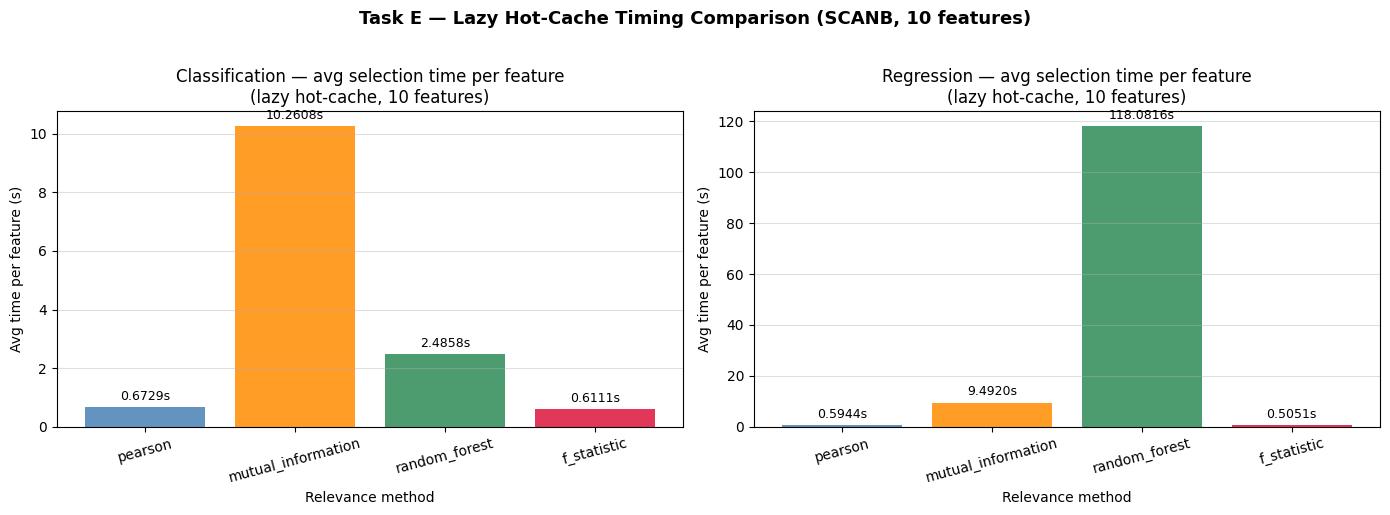

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (task, records) in zip(axes, [
    ('classification', timing_records_clf),
    ('regression',     timing_records_reg),
]):
    methods = [r['method'] for r in records]
    avgs    = [r['avg_time_per_feature_s'] for r in records]
    bar_colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
    bars = ax.bar(methods, avgs, color=bar_colors[:len(methods)], alpha=0.85)
    ax.bar_label(bars, fmt='{:.4f}s', padding=3, fontsize=9)
    ax.set_title(f'{task.capitalize()} — avg selection time per feature\n(lazy hot-cache, 10 features)', fontsize=12)
    ax.set_xlabel('Relevance method')
    ax.set_ylabel('Avg time per feature (s)')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', alpha=0.4)

fig.suptitle(
    'Task E — Lazy Hot-Cache Timing Comparison (SCANB, 10 features)',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

---

## Summary — Timing across all tasks

In [25]:
print('=== Task A — Classification (Pearson, precomputed, 50 features) ===')
print(f'  Selection time  : {result_clf.selection_time_seconds:.3f}s')
if result_clf.evaluation_time_seconds is not None:
    print(f'  Evaluation time : {result_clf.evaluation_time_seconds:.3f}s  '
          f'({len(result_clf.performance_history)} LR fits)')
print(f'  Stopping reason : {result_clf.stopping_reason}')

print()
print('=== Task B — Regression (Pearson, precomputed, 50 features) ===')
print(f'  Selection time  : {result_reg.selection_time_seconds:.3f}s')
if result_reg.evaluation_time_seconds is not None:
    print(f'  Evaluation time : {result_reg.evaluation_time_seconds:.3f}s  '
          f'({len(result_reg.performance_history)} LinReg fits)')
print(f'  Stopping reason : {result_reg.stopping_reason}')

print()
print('=== Task C — Classification non-correlation methods (precomputed, 50 features) ===')
for method, res in results_C.items():
    print(f'  {method:25s}: sel={res.selection_time_seconds:.3f}s  '
          f'eval={res.evaluation_time_seconds:.3f}s  '
          f'evals={len(res.performance_history)}')

print()
print('=== Task D — Regression non-correlation methods (precomputed, 50 features) ===')
for method, res in results_D.items():
    print(f'  {method:25s}: sel={res.selection_time_seconds:.3f}s  '
          f'eval={res.evaluation_time_seconds:.3f}s  '
          f'evals={len(res.performance_history)}')

print()
print('=== Task E — Lazy hot-cache timing (10 features) ===')
display(timing_df.set_index(['task', 'method']))

=== Task A — Classification (Pearson, precomputed, 50 features) ===
  Selection time  : 9.568s
  Evaluation time : 7.333s  (15 LR fits)
  Stopping reason : max_features_reached

=== Task B — Regression (Pearson, precomputed, 50 features) ===
  Selection time  : 9.687s
  Evaluation time : 0.183s  (15 LinReg fits)
  Stopping reason : max_features_reached

=== Task C — Classification non-correlation methods (precomputed, 50 features) ===
  mutual_information       : sel=12.254s  eval=7.556s  evals=15
  random_forest            : sel=10.044s  eval=6.898s  evals=15
  f_statistic              : sel=12.151s  eval=8.740s  evals=15

=== Task D — Regression non-correlation methods (precomputed, 50 features) ===
  mutual_information       : sel=10.412s  eval=0.150s  evals=15
  random_forest            : sel=9.995s  eval=0.152s  evals=15
  f_statistic              : sel=10.622s  eval=0.168s  evals=15

=== Task E — Lazy hot-cache timing (10 features) ===


total_selection_time_s  \
task           method                                       
classification pearson                             6.7288   
               mutual_information                102.6084   
               random_forest                      24.8578   
               f_statistic                         6.1113   
regression     pearson                             5.9445   
               mutual_information                 94.9199   
               random_forest                    1180.8156   
               f_statistic                         5.0506   

                                   avg_time_per_feature_s  
task           method                                      
classification pearson                             0.6729  
               mutual_information                 10.2608  
               random_forest                       2.4858  
               f_statistic                         0.6111  
regression     pearson                             0.5944  
               mutual_information                  9.4920  
               random_forest                     118.0816  
               f_statistic                         0.5051